# Forecasting retail demand under stockouts

A store cannot sell what is not on the shelf: recorded **sales are a censored version of
demand**. A model that ignores this reads every stockout dip as a demand drop and
under-forecasts exactly the products a planner most needs to reorder. This notebook ports
Juan Orduz's [Forecasting Retail Demand Under Stockouts](https://juanitorduz.github.io/fresh_retail_stockout/)
(built on [numpyro_forecast](https://github.com/juanitorduz/numpyro_forecast)) to
`pymc_forecast` ([issue #47](https://github.com/pymc-labs/pymc-forecast/issues/47)).

We model daily demand for a panel of store-product series from
[FreshRetailNet-50K](https://huggingface.co/datasets/Dingdong-Inc/FreshRetailNet-50K)
— 50,000 series with hourly stockout labels — with:

- a **hierarchical damped-trend model**: per-series random-walk level, damped AR(1)
  slope (a `markov_time_series` scan latent), weekly seasonality, and promotion
  covariates pooled by store;
- a **floored saturating availability factor** that multiplies expected sales: at full
  availability it is exactly 1, at zero recorded availability it falls to a learned
  floor rather than 0 — because a small share of sales happens even on days flagged
  fully out of stock (label noise the data itself reveals below);
- a **counterfactual demand forecast**: replaying the forecast with availability pinned
  to 1 turns the sales model into the unconstrained-demand estimate planners should
  order against.

The upstream example fits all 50,000 series with SVI on a GPU in about six minutes.
Here we fit a reduced panel — the top products of the highest-volume stores — with ADVI
on CPU, which keeps the notebook executable anywhere; the [closing section](#scaling-to-the-full-panel)
explains what changes at full scale.

## Prepare notebook

In [1]:
import logging
import os

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import pooch
import pymc as pm
import pytensor.tensor as pt
import xarray as xr

from pymc_forecast import (
    Forecaster,
    ForecastingModel,
    Horizon,
    build_model,
    eval_coverage,
    eval_crps,
    markov_time_series,
    periodic_repeat,
)
from pymc_forecast.data import FUTURE_DIM, TIME_DIM

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

logging.getLogger("pymc").setLevel(logging.ERROR)
logging.getLogger("pytensor").setLevel(logging.ERROR)

SEED = 42

# CI executes every example notebook end-to-end with reduced settings.
SMOKE_TEST = os.environ.get("PYMC_FORECAST_SMOKE_TEST", "0") == "1"
N_STORES = 4 if SMOKE_TEST else 10
N_PER_STORE = 10 if SMOKE_TEST else 20
NUM_STEPS = 200 if SMOKE_TEST else 40_000
NUM_SAMPLES = 50 if SMOKE_TEST else 200
BATCH_SIZE = 50

T_TRAIN = 76
HORIZON = 14

## Read data

`FreshRetailNet-50K` ships 90 days (2024-03-28 to 2024-06-25) of daily store-product
rows with hourly sales, **hourly stockout flags**, and promotion covariates. The single
training parquet holds 4.5 million rows, so we scan it lazily with polars and only ever
collect aggregates. The download (~100 MB) is cached by pooch.

In [2]:
parquet_path = pooch.retrieve(
    url="https://huggingface.co/datasets/Dingdong-Inc/FreshRetailNet-50K/resolve/main/data/train.parquet",
    known_hash="sha256:6706832db892bbae4969c19d87e07975d2543d2ba7d7d4756360654785de5a3d",
    fname="fresh_retail_train.parquet",
    path=pooch.os_cache("pymc_forecast"),
    progressbar=False,
)
data_lf = pl.scan_parquet(parquet_path)

data_lf.select(
    pl.len().alias("rows"),
    pl.col("store_id").n_unique().alias("stores"),
    pl.col("product_id").n_unique().alias("products"),
    pl.struct(["store_id", "product_id"]).n_unique().alias("series"),
    pl.col("dt").min().alias("start_date"),
    pl.col("dt").max().alias("end_date"),
).collect(engine="streaming")

rows,stores,products,series,start_date,end_date
u32,u32,u32,u32,str,str
4500000,898,865,50000,"""2024-03-28""","""2024-06-25"""


## How bad is the stockout problem?

Three facts drive the model design. First, stockouts are pervasive — most days lose at
least a few hours of shelf time. Second, hours are not equal: almost all sales happen
between 6:00 and 22:00, so an availability measure should weight each hour by its share
of sales. Third — and this is the key one — **the stockout labels are noisy**: a
meaningful share of days flagged out of stock for all 24 hours still records positive
sales. Hard-censoring sales to zero at zero availability would contradict the data;
the model needs a *floor*.

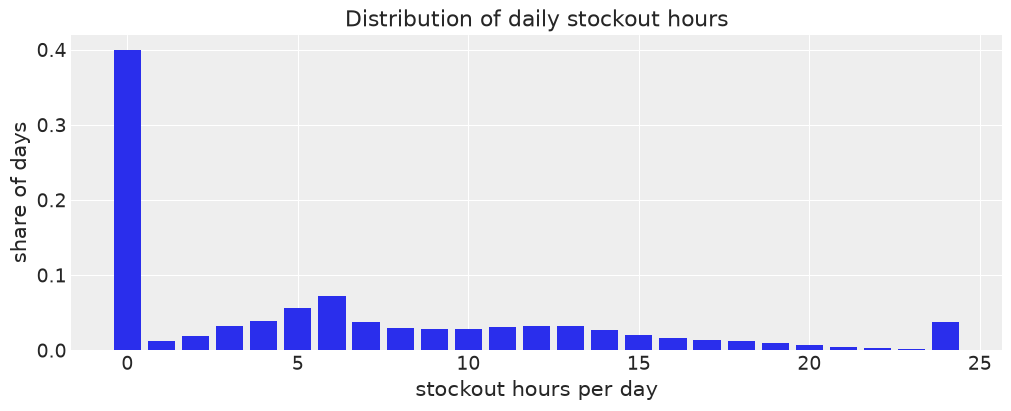

In [3]:
stockout_hours = pl.col("hours_stock_status").list.sum()

stockout_hours_df = (
    data_lf.group_by(stockout_hours.alias("stockout_hours"))
    .len()
    .sort("stockout_hours")
    .with_columns((pl.col("len") / pl.col("len").sum()).alias("share_of_days"))
    .collect(engine="streaming")
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(stockout_hours_df["stockout_hours"], stockout_hours_df["share_of_days"], color="C0")
ax.set(
    xlabel="stockout hours per day",
    ylabel="share of days",
    title="Distribution of daily stockout hours",
)
plt.show()

share of sales in the 6:00-22:00 window: 95.2%


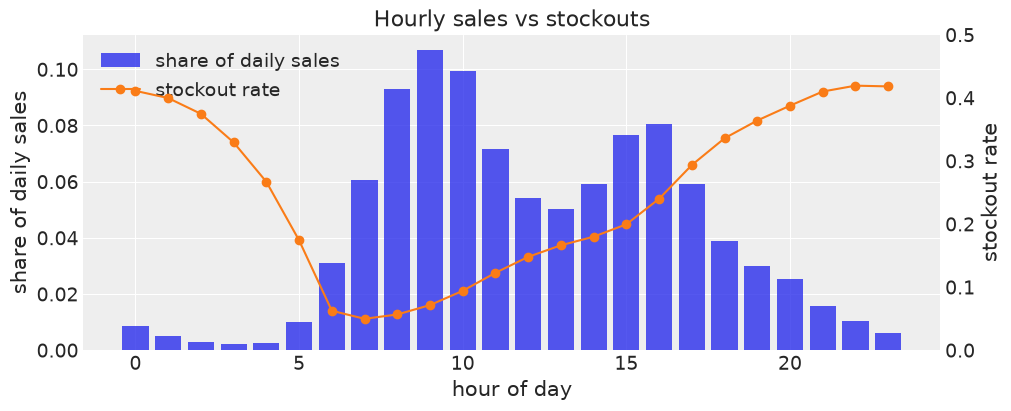

In [4]:
hourly_row = (
    data_lf.select(
        *[pl.col("hours_sale").list.get(h).sum().alias(f"sales_{h}") for h in range(24)],
        *[pl.col("hours_stock_status").list.get(h).mean().alias(f"oos_{h}") for h in range(24)],
    )
    .collect(engine="streaming")
    .row(0)
)
sales_by_hour = np.asarray(hourly_row[:24], dtype=np.float64)
stockout_rate_by_hour = np.asarray(hourly_row[24:], dtype=np.float64)
hourly_weights = sales_by_hour / sales_by_hour.sum()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(np.arange(24), hourly_weights, color="C0", alpha=0.8, label="share of daily sales")
ax_twin = ax.twinx()
ax_twin.plot(np.arange(24), stockout_rate_by_hour, "o-", color="C1", label="stockout rate")
ax_twin.grid(False)
ax_twin.set(ylabel="stockout rate", ylim=(0, 0.5))
handles, labels = ax.get_legend_handles_labels()
handles_twin, labels_twin = ax_twin.get_legend_handles_labels()
ax.legend(handles + handles_twin, labels + labels_twin, loc="upper left")
ax.set(xlabel="hour of day", ylabel="share of daily sales", title="Hourly sales vs stockouts")
print(f"share of sales in the 6:00-22:00 window: {hourly_weights[6:22].sum():.1%}")
plt.show()

The **sales-weighted availability** of a day weights each in-stock hour by its share of
global sales, so losing the 3 a.m. hour barely moves it while losing the evening peak
does:

$$a_{t,s} = \sum_{h=0}^{23} w_h \, (1 - \text{stockout}_{t,s,h}),
\qquad w_h = \frac{\text{global sales in hour } h}{\text{total global sales}}.$$

Binning all 4.5M day-rows by this availability and averaging each series' *scaled* sales
(each series divided by its own mean, so 1 is an average day) traces the curve the model
must reproduce — including its most awkward feature: the mean scaled sales at **zero**
availability is clearly positive.

empirical floor at zero availability: 0.037


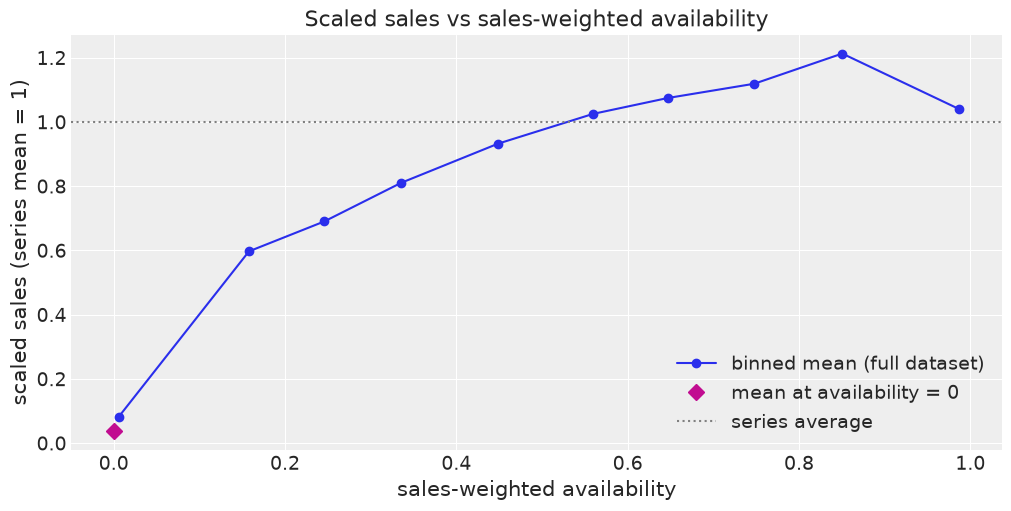

In [5]:
def sales_weighted_availability(weights):
    """In-stock share of the day, each hour weighted by its share of global sales."""
    return pl.sum_horizontal(
        [(1 - pl.col("hours_stock_status").list.get(h)) * float(weights[h]) for h in range(24)]
    ).alias("availability")


scaled_sales = pl.col("sale_amount") / pl.col("sale_amount").mean().over("store_id", "product_id")
availability_sales_lf = data_lf.with_columns(
    sales_weighted_availability(hourly_weights), scaled_sales.alias("scaled_sales")
)
factor_curve_df = (
    availability_sales_lf.group_by(
        (pl.col("availability") * 10).floor().clip(0, 9).alias("availability_bin")
    )
    .agg(
        pl.col("availability").mean().alias("mean_availability"),
        pl.col("scaled_sales").mean().alias("mean_scaled_sales"),
    )
    .sort("availability_bin")
    .collect(engine="streaming")
)
empirical_floor = float(
    availability_sales_lf.filter(pl.col("availability") == 0)
    .select(pl.col("scaled_sales").mean())
    .collect(engine="streaming")
    .item()
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    factor_curve_df["mean_availability"],
    factor_curve_df["mean_scaled_sales"],
    "o-",
    color="C0",
    label="binned mean (full dataset)",
)
ax.plot(0.0, empirical_floor, "D", color="C3", markersize=8, label="mean at availability = 0")
ax.axhline(1.0, color="gray", linestyle=":", label="series average")
ax.legend(loc="lower right")
ax.set(
    xlabel="sales-weighted availability",
    ylabel="scaled sales (series mean = 1)",
    title="Scaled sales vs sales-weighted availability",
)
print(f"empirical floor at zero availability: {empirical_floor:.3f}")
plt.show()

## Assemble the panel

We keep the `N_PER_STORE` highest-selling products of the `N_STORES` highest-volume
stores (ranked on the training window only, so no test information leaks into the panel
choice) — a reduced panel with a real store hierarchy for the pooled covariate effects.
Alongside availability we carry four regression features: discount magnitude (`discount
== 0` rows are unpriced placeholders, not free giveaways), a promotion-activity flag, a
holiday flag, and a post-launch step — panel-mean sales roughly double on 2024-04-27,
a platform-wide launch the upstream post identifies, and without the step covariate the
random-walk levels would have to absorb it.

In [6]:
in_train_window = pl.col("dt").str.to_date() < (
    pl.col("dt").str.to_date().min() + pl.duration(days=T_TRAIN)
)
series_sales_lf = (
    data_lf.filter(in_train_window)
    .group_by("store_id", "product_id")
    .agg(pl.col("sale_amount").sum().alias("total_sales"))
)
top_stores_lf = (
    series_sales_lf.group_by("store_id")
    .agg(pl.col("total_sales").sum())
    .sort("total_sales", descending=True)
    .head(N_STORES)
    .select("store_id")
)
top_series_df = (
    series_sales_lf.join(top_stores_lf, on="store_id")
    .sort("total_sales", descending=True)
    .group_by("store_id", maintain_order=True)
    .head(N_PER_STORE)
    .collect(engine="streaming")
)

cleaned_discount = (
    pl.when(pl.col("discount") > 0)
    .then((1 - pl.col("discount")).clip(0.0, 1.0))
    .otherwise(0.0)
    .alias("discount_magnitude")
)
panel_df = (
    data_lf.join(
        top_series_df.lazy().select("store_id", "product_id"), on=["store_id", "product_id"]
    )
    .with_columns(
        pl.col("dt").str.to_date(),
        pl.concat_str(["store_id", "product_id"], separator="::").alias("unique_id"),
        sales_weighted_availability(hourly_weights),
        cleaned_discount,
    )
    .select(
        "dt",
        "unique_id",
        "store_id",
        "sale_amount",
        "availability",
        "discount_magnitude",
        pl.col("activity_flag").cast(pl.Float64),
        pl.col("holiday_flag").cast(pl.Float64),
    )
    .collect(engine="streaming")
    .sort("unique_id", "dt")
)

series_ids = panel_df["unique_id"].unique().sort().to_list()
dates = panel_df["dt"].unique().sort().to_numpy()


def make_pivot(value):
    """Dense (date x series) matrix of one panel column, in series_ids order."""
    pivot_df = panel_df.pivot(index="dt", on="unique_id", values=value).sort("dt")
    matrix = pivot_df.select(series_ids).to_numpy().astype(np.float64)
    if matrix.shape != (len(dates), len(series_ids)) or np.isnan(matrix).any():
        raise ValueError(f"unexpected pivot for {value!r}: shape {matrix.shape}")
    return matrix


panel_ds = xr.Dataset(
    {
        name: ((TIME_DIM, "series"), make_pivot(name))
        for name in [
            "sale_amount",
            "availability",
            "discount_magnitude",
            "activity_flag",
            "holiday_flag",
        ]
    },
    coords={TIME_DIM: dates, "series": series_ids},
)
RAMP_DATE = np.datetime64("2024-04-27")
panel_ds["post_ramp"] = (
    (panel_ds[TIME_DIM] >= RAMP_DATE).astype(np.float64).broadcast_like(panel_ds["sale_amount"])
)
print("panel:", dict(panel_ds.sizes))
print("window:", dates[0], "->", dates[-1], f"| train {T_TRAIN} days, test {HORIZON} days")

panel: {'time': 90, 'series': 200}
window: 2024-03-28 -> 2024-06-25 | train 76 days, test 14 days


Each series is scaled by its **training-window** mean (computed inside the train fold,
so no future level leaks in): on the scaled axis 1 is an average day for every series
and one set of priors fits the whole panel. Covariates are stacked into a single labeled
`(time, input, series)` array — availability first, then the four regression features.

In [7]:
scale = panel_ds["sale_amount"].isel({TIME_DIM: slice(None, T_TRAIN)}).mean(TIME_DIM)
y_scaled = panel_ds["sale_amount"] / scale
y_train = y_scaled.isel({TIME_DIM: slice(None, T_TRAIN)})
y_test = panel_ds["sale_amount"].isel({TIME_DIM: slice(T_TRAIN, None)})

COVARIATE_NAMES = ["discount_magnitude", "activity_flag", "holiday_flag", "post_ramp"]
INPUT_NAMES = ["availability", *COVARIATE_NAMES]
covariates = panel_ds[INPUT_NAMES].to_dataarray(dim="input").transpose(TIME_DIM, "input", "series")
covariates_train = covariates.isel({TIME_DIM: slice(None, T_TRAIN)})

series_store = panel_df.select("unique_id", "store_id").unique().sort("unique_id")
store_ids = sorted(series_store["store_id"].unique().to_list())
store_lookup = {store: i for i, store in enumerate(store_ids)}
series_to_store = np.array([store_lookup[s] for s in series_store["store_id"].to_list()])

first_weekday = pd.Timestamp(dates[0]).weekday()
DAY_NAMES = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_labels = [DAY_NAMES[(first_weekday + offset) % 7] for offset in range(7)]

print(f"{len(series_ids)} series in {len(store_ids)} stores; first day is a {dow_labels[0]}")
print(
    "sale units per scaled unit:",
    f"min {float(scale.min()):.1f} | median {float(scale.median()):.1f} | "
    f"max {float(scale.max()):.1f}",
)

200 series in 10 stores; first day is a Thu
sale units per scaled unit: min 1.7 | median 2.9 | max 8.5


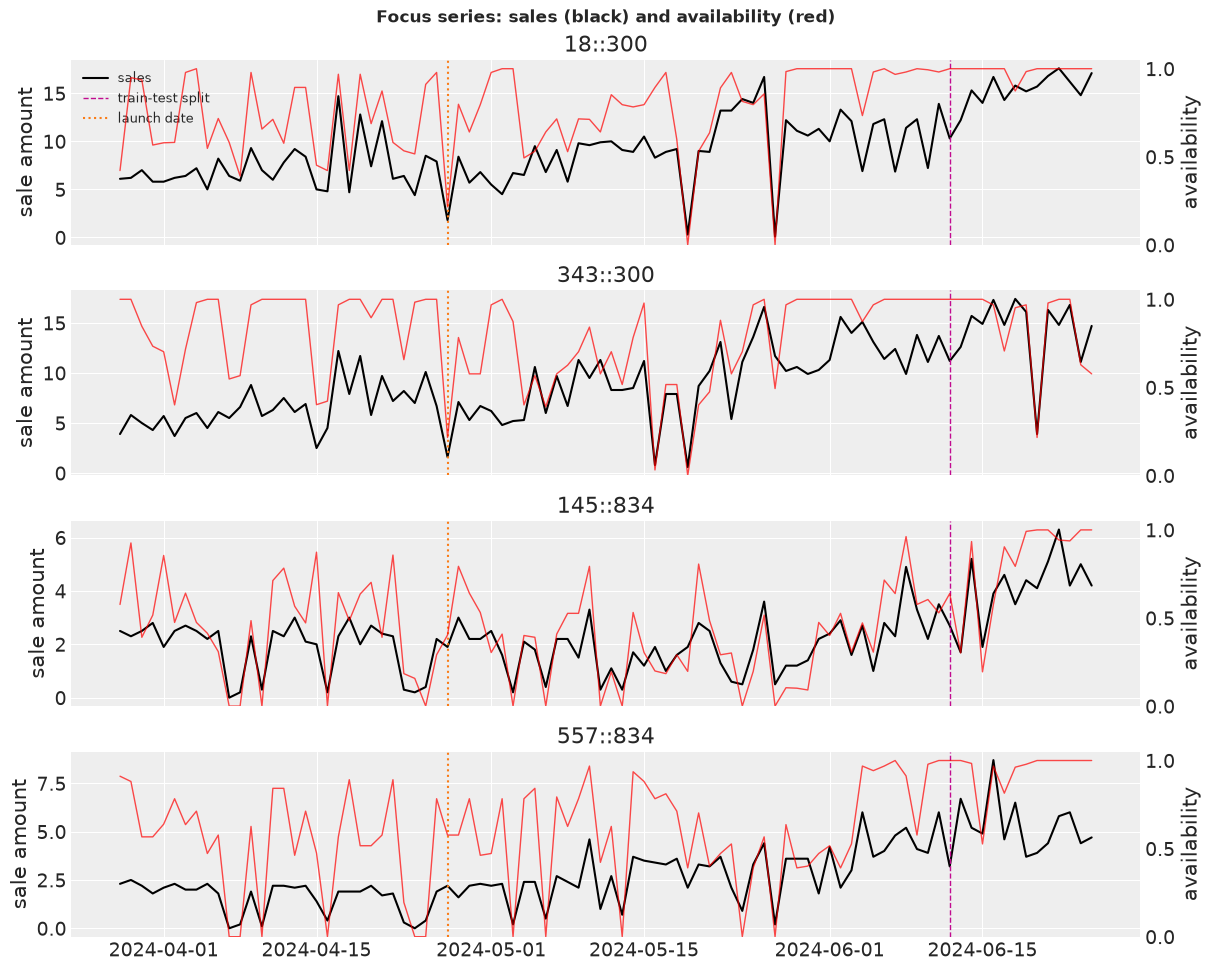

In [8]:
total_sales = panel_ds["sale_amount"].sum(TIME_DIM)
zero_availability_days = (panel_ds["availability"] == 0.0).sum(TIME_DIM)
FOCUS_SERIES = list(
    dict.fromkeys(
        [str(s) for s in total_sales.to_series().nlargest(2).index]
        + [str(s) for s in zero_availability_days.to_series().nlargest(2).index]
    )
)

fig, axes = plt.subplots(
    len(FOCUS_SERIES), 1, figsize=(12, 2.4 * len(FOCUS_SERIES)), sharex=True, layout="constrained"
)
for ax, label in zip(axes, FOCUS_SERIES, strict=True):
    ax.plot(dates, panel_ds["sale_amount"].sel(series=label), color="black", lw=1.5, label="sales")
    ax.axvline(dates[T_TRAIN], color="C3", ls="--", lw=1, label="train-test split")
    ax.axvline(RAMP_DATE, color="C1", ls=":", lw=1.5, label="launch date")
    ax.set(title=label, ylabel="sale amount")
    ax_twin = ax.twinx()
    ax_twin.plot(dates, panel_ds["availability"].sel(series=label), color="red", lw=1, alpha=0.7)
    ax_twin.grid(False)
    ax_twin.set(ylabel="availability", ylim=(0, 1.05))
axes[0].legend(loc="upper left", fontsize=9)
fig.suptitle("Focus series: sales (black) and availability (red)", fontweight="bold")
plt.show()

## The availability factor

The model multiplies expected sales by a **floored, saturating availability factor**

$$f_{t,s} = \phi_s + (1 - \phi_s)\,
\frac{1 - e^{-b_s\, a_{t,s}}}{1 - e^{-b_s}},$$

which is exactly 1 at full availability, falls to a learned floor
$\phi_s \sim \mathrm{Beta}(2, 18)$ (prior mean ≈ 0.1, covering the ~4% empirical
floor) at zero availability, and bends in between with saturation rate
$b_s \sim \mathrm{LogNormal}(1, 0.5)$: a large $b_s$ means a customer who wants the
product almost always finds it during the hours it is in stock, so partial stockouts
barely hurt. The floor is what keeps zero-availability days with positive sales from
collapsing the likelihood — hard censoring (a factor of 0) would assign them zero
expected sales *and* zero noise.

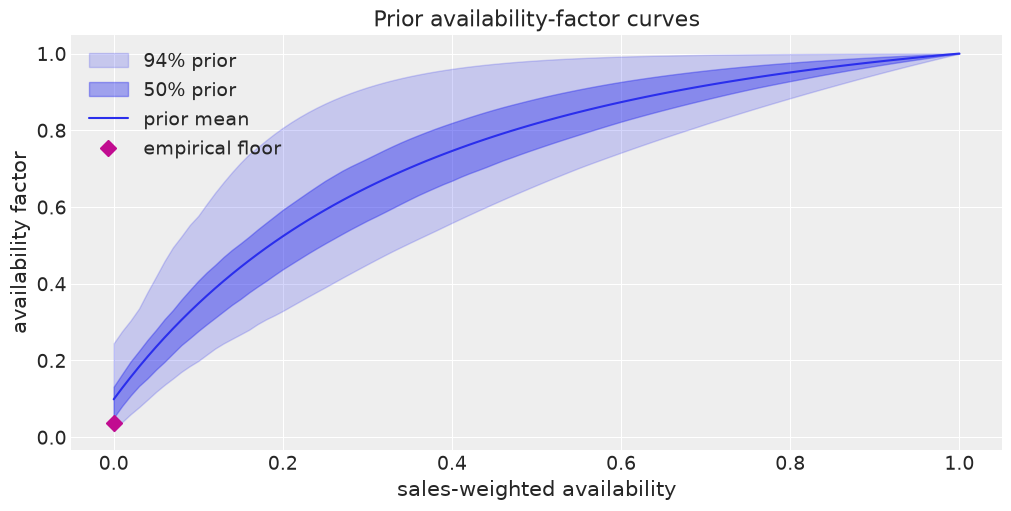

In [9]:
rng = np.random.default_rng(SEED)
availability_grid = np.linspace(0.0, 1.0, 101)
floor_prior = rng.beta(2.0, 18.0, size=500)
b_prior = rng.lognormal(1.0, 0.5, size=500)


def availability_factor(availability, b_avail, floor):
    """Floored, normalized saturating availability factor (NumPy version)."""
    saturation = np.expm1(-b_avail * availability) / np.expm1(-b_avail)
    return floor + (1.0 - floor) * saturation


factor_prior = availability_factor(
    availability_grid[None, :], b_prior[:, None], floor_prior[:, None]
)
quantiles = np.quantile(factor_prior, [0.03, 0.25, 0.75, 0.97], axis=0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(
    availability_grid, quantiles[0], quantiles[3], color="C0", alpha=0.2, label="94% prior"
)
ax.fill_between(
    availability_grid, quantiles[1], quantiles[2], color="C0", alpha=0.4, label="50% prior"
)
ax.plot(availability_grid, factor_prior.mean(axis=0), color="C0", label="prior mean")
ax.plot(0.0, empirical_floor, "D", color="C3", markersize=8, label="empirical floor")
ax.legend(loc="upper left")
ax.set(
    xlabel="sales-weighted availability",
    ylabel="availability factor",
    title="Prior availability-factor curves",
)
plt.show()

## Model

The full generative model, per series $s$ and day $t$ on the scaled axis:

$$
\begin{aligned}
\mu_{t,s} &= f_{t,s} \left( \ell_{t,s} + \gamma_{d(t),s} + \textstyle\sum_c \beta_{c,s}\, x_{c,t,s} \right) \\
\ell_{t,s} &= \ell_0{}_{,s} + \textstyle\sum_{u \le t} \sigma^{\text{drift}}_s \delta_{u,s} + \textstyle\sum_{u \le t} r_{u,s},
  \qquad \delta_{u,s} \sim \mathrm{N}(0, 1) \\
r_{t,s} &\sim \mathrm{N}(\phi^{\text{trend}}_s\, r_{t-1,s},\ \tau^{\text{trend}}_s)
  \qquad \text{(damped AR(1) slope)} \\
\gamma_{\cdot,s} &\sim \mathrm{ZeroSumNormal}(\sigma_\gamma) \quad \text{over the 7 weekdays} \\
\beta_{c,s} &\sim \mathrm{N}(\mu^{\text{store}}_{c,m(s)},\ \sigma^{\text{store}}_{c,m(s)})
  \qquad \text{(pooled by store, non-centered)} \\
y_{t,s} &\sim \mathrm{N}\!\left(\mu_{t,s},\ f_{t,s}\big(\sigma_s + \lambda_s\,\mathrm{softplus}(\ell_{t,s})\big) + 0.02\right)
\end{aligned}
$$

Mapping to `pymc_forecast` primitives:

- the drift innovations are a `time_series` latent — in-sample steps live on `"time"`,
  forecast steps on a separate `drift_future` variable the posterior never sees;
- the damped slope is a `markov_time_series` scan latent whose forecast segment is
  seeded by the final in-sample state;
- everything carries **named dims** (`series`, `store`, `covariate`, `day_of_week`), so
  the posterior comes back fully labeled;
- the noise scale is also multiplied by $f_{t,s}$ — stockout days have less to explain —
  and the constant basal term $0.02$ keeps the likelihood bounded at exact-zero sales
  (a learned basal scale collapses there and destabilizes the optimization);
- the upstream model learns the reparameterization centeredness with `LocScaleReparam`;
  we use plain non-centered parameterizations, the standard PyMC idiom.

In [10]:
class FreshRetailModel(ForecastingModel):
    """Hierarchical damped-trend panel model with a floored availability factor."""

    def __init__(self, series_to_store, store_ids, covariate_names, dow_labels):
        super().__init__()
        self.series_to_store = series_to_store
        self.store_ids = store_ids
        self.covariate_names = covariate_names
        self.dow_labels = dow_labels

    def model(self, h: Horizon, covariates: xr.DataArray) -> None:
        model = pm.modelcontext(None)
        model.add_coord("store", self.store_ids)
        model.add_coord("covariate", self.covariate_names)
        model.add_coord("day_of_week", self.dow_labels)
        n_series = len(model.coords["series"])

        values = covariates.transpose(TIME_DIM, "input", "series").values
        availability = values[:, 0, :]  # (duration, series)
        features = values[:, 1:, :]  # (duration, covariate, series)

        # store-level hyperpriors for the covariate effects
        b_loc_store = pm.Normal("b_loc_store", 0.0, 0.5, dims=("covariate", "store"))
        b_scale_store = pm.HalfNormal("b_scale_store", 0.3, dims=("covariate", "store"))
        b_z = pm.Normal("b_z", 0.0, 1.0, dims=("covariate", "series"))
        b = pm.Deterministic(
            "b",
            b_loc_store[:, self.series_to_store] + b_scale_store[:, self.series_to_store] * b_z,
            dims=("covariate", "series"),
        )

        # per-series dynamics, seasonality, availability response, and noise
        drift_scale = pm.LogNormal("drift_scale", -3.0, 1.0, dims="series")
        phi_trend = pm.Beta("phi_trend", 8.0, 2.0, dims="series")
        tau_trend = pm.LogNormal("tau_trend", -4.0, 1.0, dims="series")
        init_level = pm.Normal("init_level", 1.0, 0.5, dims="series")
        seasonal_scale = pm.HalfNormal("seasonal_scale", 0.2)
        seasonal = pm.ZeroSumNormal(
            "seasonal", sigma=seasonal_scale, dims=("series", "day_of_week")
        )
        b_avail = pm.LogNormal("b_avail", 1.0, 0.5, dims="series")
        floor = pm.Beta("floor", 2.0, 18.0, dims="series")
        sigma = pm.HalfNormal("sigma", 0.5, dims="series")
        noise_loading = pm.HalfNormal("noise_loading", 0.2, dims="series")

        # random-walk drift (non-centered) and damped AR(1) slope over the horizon
        drift_z = self.time_series(
            "drift",
            lambda name, dims: pm.Normal(name, 0.0, 1.0, dims=dims),
            dims=("series",),
        )
        slope = markov_time_series(
            h,
            "slope",
            np.zeros(n_series),
            lambda z, phi, tau: pm.Normal.dist(phi * z, tau),
            params=(phi_trend, tau_trend),
            dims=("series",),
        )

        level = init_level + pt.cumsum(drift_z * drift_scale, axis=0) + pt.cumsum(slope, axis=0)
        seasonal_rep = periodic_repeat(seasonal.T, h.duration, axis=0, period=7)
        contribution = (features * b[None, :, :]).sum(axis=1)
        factor = floor + (1.0 - floor) * pt.expm1(-b_avail * availability) / pt.expm1(-b_avail)
        mu = factor * (level + seasonal_rep + contribution)
        sigma_t = factor * (sigma + noise_loading * pt.softplus(level)) + 0.02

        t_obs = h.t_obs

        def obs_fn(name, latent, dims, observed):
            noise = sigma_t[:t_obs] if dims[0] == TIME_DIM else sigma_t[t_obs:]
            return pm.Normal(name, latent, noise, dims=dims, observed=observed)

        self.predict(obs_fn, mu, dims=("series",))


model = FreshRetailModel(series_to_store, store_ids, COVARIATE_NAMES, dow_labels)
build_model(model, y_train, covariates_train)

   b_loc_store ~ Normal(0, 0.5)
 b_scale_store ~ HalfNormal(0, 0.3)
           b_z ~ Normal(0, 1)
   drift_scale ~ LogNormal(-3, 1)
     phi_trend ~ Beta(8, 2)
     tau_trend ~ LogNormal(-4, 1)
    init_level ~ Normal(1, 0.5)
seasonal_scale ~ HalfNormal(0, 0.2)
      seasonal ~ ZeroSumNormal(seasonal_scale, <constant>)
       b_avail ~ LogNormal(1, 0.5)
         floor ~ Beta(2, 18)
         sigma ~ HalfNormal(0, 0.5)
 noise_loading ~ HalfNormal(0, 0.2)
         drift ~ Normal(0, 1)
         slope ~ CustomDist_slope(<constant>, phi_trend, tau_trend)
             b = Deterministic(f(b_z, b_loc_store, b_scale_store))
            mu = Deterministic(f(floor, b, seasonal, slope, init_level, b_avail, drift, drift_scale))
           obs ~ Normal(f(floor, b, seasonal, slope, init_level, b_avail, drift, drift_scale), f(sigma, floor, noise_loading, slope, b_avail, init_level, drift, drift_scale))

## Inference with ADVI

Mean-field ADVI over roughly $2 \times 76 \times 200$ time latents plus the per-series
parameters. The upstream run uses a one-cycle schedule with 60k steps for the 50k-series
panel; plain Adam is enough at this scale.

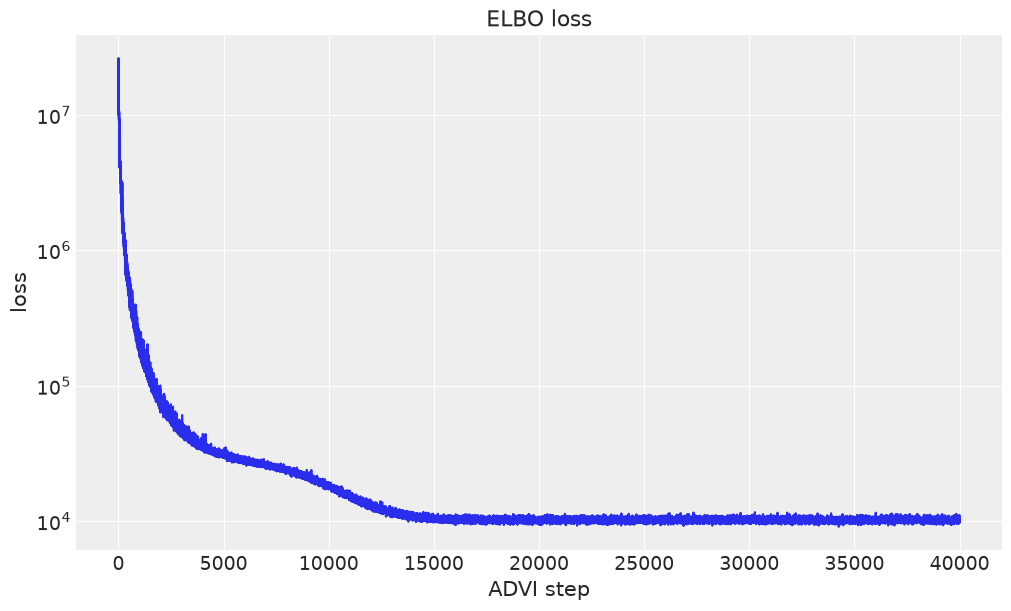

In [11]:
forecaster = Forecaster(
    model,
    y_train,
    covariates_train,
    optimizer=0.01,
    num_steps=NUM_STEPS,
    random_seed=SEED,
)

fig, ax = plt.subplots()
ax.plot(forecaster.losses)
ax.set(title="ELBO loss", xlabel="ADVI step", ylabel="loss", yscale="log")
plt.show()

## Forecast

The test-window availability is **known** (it is observed inventory data), so the
forecast conditions on it through the full-horizon covariates. We draw one posterior and
reuse it for the in-sample predictive, the forecast, and the counterfactual below, so
all three are conditioned on the same parameter draws.

Both predictive calls pass `batch_size`: the posterior is processed in blocks of at most
`BATCH_SIZE` draws, bounding the working memory of each pass. At this panel size that is
a demonstration; at the upstream scale (50,000 series) it is what keeps posterior
predictive sampling from exhausting memory — the change this notebook's issue calls out
([numpyro_forecast#65](https://github.com/juanitorduz/numpyro_forecast/pull/65)).

In [12]:
posterior = forecaster.draw_posterior(NUM_SAMPLES, random_seed=SEED)

pp_idata = forecaster.predict_in_sample(
    posterior=posterior, batch_size=BATCH_SIZE, random_seed=SEED
)
fc_idata = forecaster.forecast(
    covariates, posterior=posterior, batch_size=BATCH_SIZE, random_seed=SEED
)

# back to the original sales scale (clipped at zero: sales are non-negative)
pred_train = (pp_idata["posterior_predictive"]["obs"] * scale).clip(min=0.0)
pred_test = (fc_idata["predictions"]["forecast"] * scale).clip(min=0.0)
print("forecast dims:", dict(pred_test.sizes))

forecast dims: {'chain': 1, 'draw': 200, 'time_future': 14, 'series': 200}


## Evaluation

CRPS (lower is better) and central-interval coverage on the original sales scale,
against a **seasonal-naive ensemble**: the weekday-aligned historical windows of each
series, stacked as an empirical forecast distribution — the baseline any model must
beat on strongly weekly data.

In [13]:
def seasonal_naive_ensemble(y_history, horizon, period=7):
    """Weekday-aligned historical windows stacked as an empirical forecast ensemble."""
    t_hist = y_history.shape[0]
    windows = []
    k = 1
    while t_hist - k * period >= 0:
        start = t_hist - k * period
        if start + horizon <= t_hist:
            windows.append(y_history[start : start + horizon])
        k += 1
    return np.stack(windows)


truth_train = panel_ds["sale_amount"].isel({TIME_DIM: slice(None, T_TRAIN)})
truth_test = y_test.rename({TIME_DIM: FUTURE_DIM})
naive_test = xr.DataArray(
    seasonal_naive_ensemble(truth_train.values, HORIZON),
    dims=("draw", FUTURE_DIM, "series"),
    coords={FUTURE_DIM: truth_test[FUTURE_DIM], "series": series_ids},
)

results = pd.DataFrame(
    {
        "split": ["model (train)", "model (test)", "seasonal naive (test)"],
        "crps": [
            eval_crps(pred_train, truth_train),
            eval_crps(pred_test, truth_test),
            eval_crps(naive_test, truth_test),
        ],
        "coverage_94": [
            eval_coverage(pred_train, truth_train, alpha=0.94),
            eval_coverage(pred_test, truth_test, alpha=0.94),
            np.nan,
        ],
        "coverage_50": [
            eval_coverage(pred_train, truth_train, alpha=0.5),
            eval_coverage(pred_test, truth_test, alpha=0.5),
            np.nan,
        ],
    }
)
results.round(3)

,split,crps,coverage_94,coverage_50
0,model (train),0.550,0.981,0.625
1,model (test),0.805,0.925,0.514
2,seasonal naive (test),1.131,NaN,NaN


## Forecast visualization

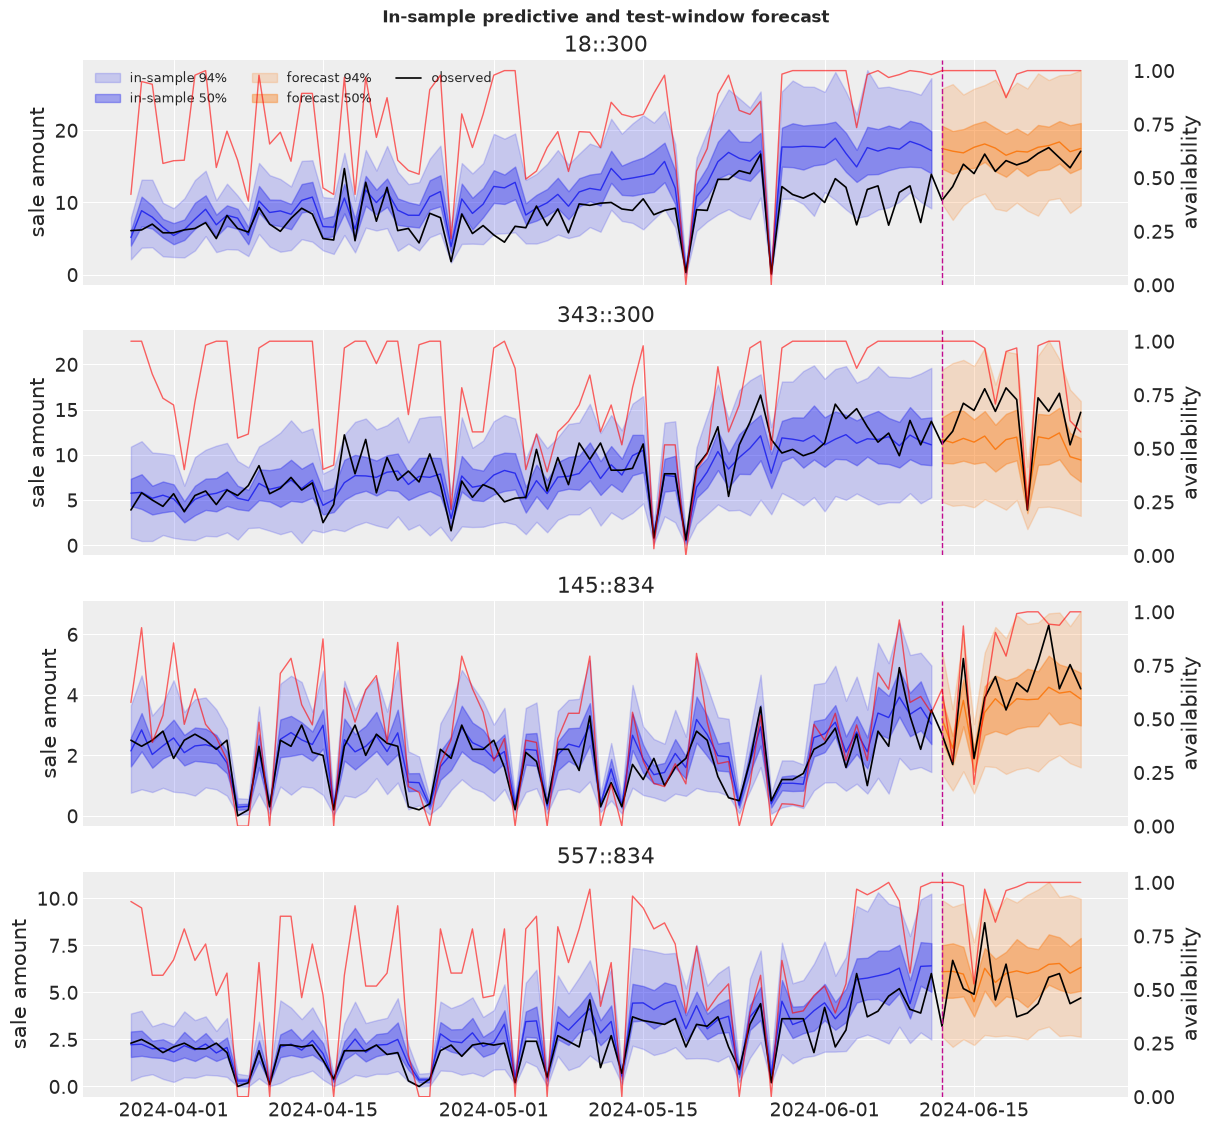

In [14]:
def plot_band(ax, samples, dim, color, label):
    """Median line and 50%/94% quantile bands of a (chain, draw, time, ...) slice."""
    time_axis = samples[dim].values
    quantiles = samples.quantile([0.03, 0.25, 0.5, 0.75, 0.97], dim=("chain", "draw"))
    ax.fill_between(
        time_axis,
        quantiles.sel(quantile=0.03),
        quantiles.sel(quantile=0.97),
        color=color,
        alpha=0.2,
        label=f"{label} 94%",
    )
    ax.fill_between(
        time_axis,
        quantiles.sel(quantile=0.25),
        quantiles.sel(quantile=0.75),
        color=color,
        alpha=0.4,
        label=f"{label} 50%",
    )
    ax.plot(time_axis, quantiles.sel(quantile=0.5), color=color, lw=1)


fig, axes = plt.subplots(
    len(FOCUS_SERIES), 1, figsize=(12, 2.8 * len(FOCUS_SERIES)), sharex=True, layout="constrained"
)
for ax, label in zip(axes, FOCUS_SERIES, strict=True):
    plot_band(ax, pred_train.sel(series=label), TIME_DIM, "C0", "in-sample")
    plot_band(ax, pred_test.sel(series=label), FUTURE_DIM, "C1", "forecast")
    ax.plot(
        dates, panel_ds["sale_amount"].sel(series=label), color="black", lw=1.2, label="observed"
    )
    ax.axvline(dates[T_TRAIN], color="C3", ls="--", lw=1)
    ax.set(title=label, ylabel="sale amount")
    ax_twin = ax.twinx()
    ax_twin.plot(dates, panel_ds["availability"].sel(series=label), color="red", lw=1, alpha=0.6)
    ax_twin.grid(False)
    ax_twin.set(ylabel="availability", ylim=(0, 1.05))
axes[0].legend(loc="upper left", fontsize=9, ncols=3)
fig.suptitle("In-sample predictive and test-window forecast", fontweight="bold")
plt.show()

## Demand, not sales: the counterfactual forecast

The whole point of separating demand from availability: replaying the same posterior
with **availability pinned to 1** over the test window forecasts what customers *would*
buy fully in stock — the quantity to order against. On series with healthy availability
the two forecasts coincide; on stockout-heavy series the demand forecast sits above the
sales forecast, and the gap is the expected lost sales.

In [15]:
covariates_demand = covariates.copy(deep=True)
covariates_demand.loc[{"input": "availability", TIME_DIM: slice(dates[T_TRAIN], None)}] = 1.0

fc_demand_idata = forecaster.forecast(
    covariates_demand, posterior=posterior, batch_size=BATCH_SIZE, random_seed=SEED
)
pred_test_demand = (fc_demand_idata["predictions"]["forecast"] * scale).clip(min=0.0)

demand_total = pred_test_demand.mean(("chain", "draw")).sum(FUTURE_DIM)
sales_total = pred_test.mean(("chain", "draw")).sum(FUTURE_DIM)
series_uplift = demand_total / sales_total - 1
panel_uplift = float(demand_total.sum() / sales_total.sum() - 1)
print(f"expected demand above the sales forecast on the test window: {panel_uplift:+.1%}")
print(
    f"largest per-series uplift: {float(series_uplift.max()):+.1%} "
    f"(series {series_uplift.idxmax().values!s})"
)

expected demand above the sales forecast on the test window: +9.2%
largest per-series uplift: +50.2% (series 18::70)


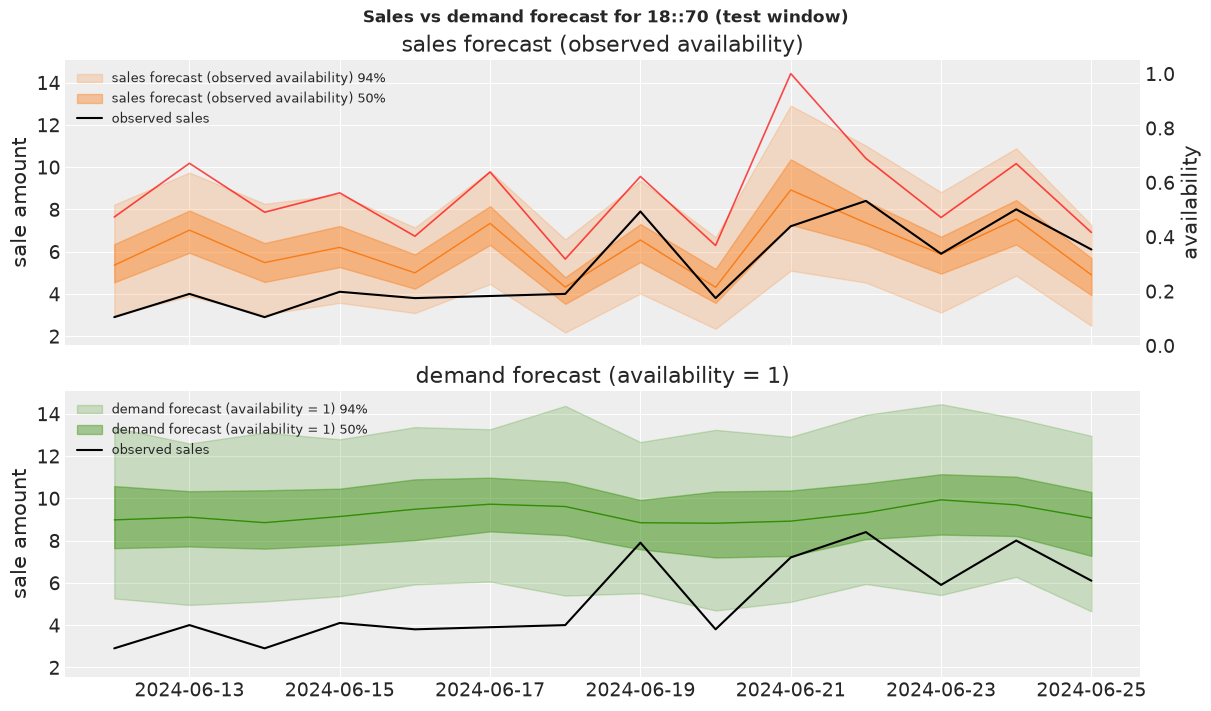

In [16]:
comparison_id = str(series_uplift.idxmax().values)
test_dates = dates[T_TRAIN:]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, sharey=True, layout="constrained")
for ax, pred, color, label in (
    (axes[0], pred_test, "C1", "sales forecast (observed availability)"),
    (axes[1], pred_test_demand, "C2", "demand forecast (availability = 1)"),
):
    plot_band(ax, pred.sel(series=comparison_id), FUTURE_DIM, color, label)
    ax.plot(
        test_dates, y_test.sel(series=comparison_id), color="black", lw=1.5, label="observed sales"
    )
    ax.set(title=label, ylabel="sale amount")
    ax.legend(loc="upper left", fontsize=9)
ax_twin = axes[0].twinx()
ax_twin.plot(
    test_dates,
    panel_ds["availability"].isel({TIME_DIM: slice(T_TRAIN, None)}).sel(series=comparison_id),
    color="red",
    lw=1.2,
    alpha=0.7,
)
ax_twin.grid(False)
ax_twin.set(ylabel="availability", ylim=(0, 1.05))
fig.suptitle(f"Sales vs demand forecast for {comparison_id} (test window)", fontweight="bold")
plt.show()

## Did the model learn the availability curve?

Push the posterior `floor` and `b_avail` draws through the factor formula and compare
the panel-mean posterior curve with the empirical binned curve from the EDA (rescaled so
its full-availability bin is 1, matching the factor's normalization).

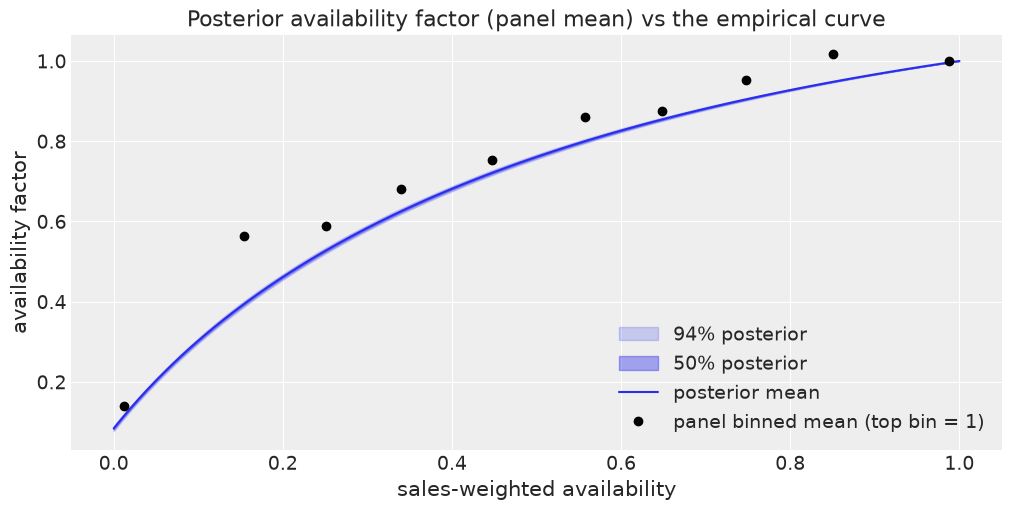

In [17]:
post = posterior[["floor", "b_avail"]].stack(sample=("chain", "draw"))
factor_draws = availability_factor(
    availability_grid[None, None, :],
    post["b_avail"].values.T[:, :, None],
    post["floor"].values.T[:, :, None],
)  # (sample, series, grid)
factor_panel = factor_draws.mean(axis=1)
post_quantiles = np.quantile(factor_panel, [0.03, 0.25, 0.75, 0.97], axis=0)

train_availability = panel_ds["availability"].isel({TIME_DIM: slice(None, T_TRAIN)})
train_scaled = y_scaled.isel({TIME_DIM: slice(None, T_TRAIN)})
bins = (train_availability * 10).astype(int).clip(0, 9).rename("availability_bin")
bin_availability = train_availability.groupby(bins).mean(...)
bin_sales = train_scaled.groupby(bins).mean(...)
top_bin = float(bin_sales.isel(availability_bin=-1))

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(
    availability_grid,
    post_quantiles[0],
    post_quantiles[3],
    color="C0",
    alpha=0.2,
    label="94% posterior",
)
ax.fill_between(
    availability_grid,
    post_quantiles[1],
    post_quantiles[2],
    color="C0",
    alpha=0.4,
    label="50% posterior",
)
ax.plot(availability_grid, factor_panel.mean(axis=0), color="C0", label="posterior mean")
ax.plot(
    bin_availability,
    bin_sales / top_bin,
    "o",
    color="black",
    label="panel binned mean (top bin = 1)",
)
ax.legend(loc="lower right")
ax.set(
    xlabel="sales-weighted availability",
    ylabel="availability factor",
    title="Posterior availability factor (panel mean) vs the empirical curve",
)
plt.show()

## The store hierarchy at work

Because everything is labeled, inspecting the pooling is a `sel` away: each series'
discount effect shrinks toward its store's location.

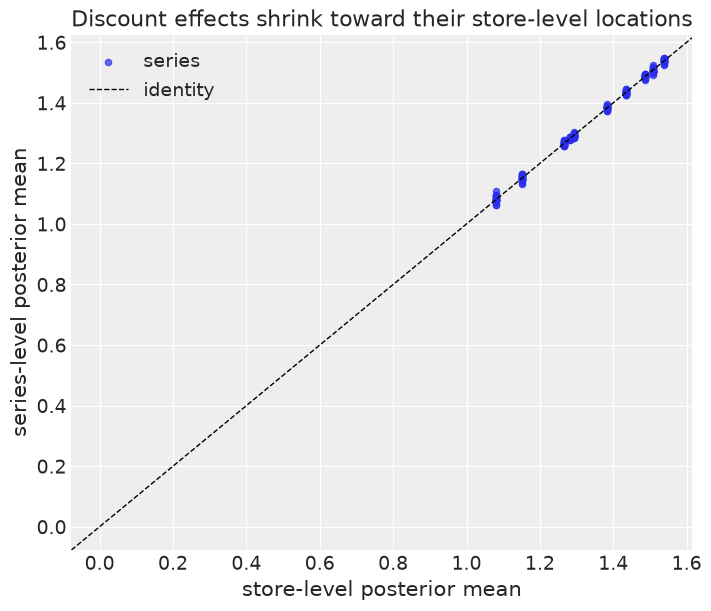

In [18]:
b_series = posterior["b"].sel(covariate="discount_magnitude").mean(("chain", "draw"))
b_store = posterior["b_loc_store"].sel(covariate="discount_magnitude").mean(("chain", "draw"))
b_store_per_series = b_store.values[series_to_store]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(b_store_per_series, b_series.values, color="C0", alpha=0.7, s=20, label="series")
ax.axline((0.0, 0.0), slope=1.0, color="black", ls="--", lw=1, label="identity")
ax.legend(loc="upper left")
ax.set(
    xlabel="store-level posterior mean",
    ylabel="series-level posterior mean",
    title="Discount effects shrink toward their store-level locations",
)
plt.show()

(scaling-to-the-full-panel)=
## Scaling to the full panel

This notebook fits a few hundred series so it runs anywhere on CPU. The upstream
example fits all **50,000 series** — the changes that matter at that scale:

- **Inference.** The upstream run uses NumPyro SVI on a GPU (60k steps with a one-cycle
  schedule, ~6 minutes). PyMC's ADVI runs on CPU; at panel widths this model remains
  embarrassingly parallel across series, so wall time grows roughly linearly with
  `N_STORES x N_PER_STORE`. For full-scale runs consider `HMCForecaster` with
  `nuts_sampler="numpyro"` or `"nutpie"` to move the heavy lifting to a compiled/GPU
  backend.
- **Predictive memory — the reason `batch_size` exists.** At 50k series a single
  posterior-predictive pass materializes `draws x time x series` arrays per recorded
  variable (500 draws x 90 days x 50k series is ~18 GB per variable in float64).
  `forecast(..., batch_size=50)` processes the posterior in draw blocks (the port of
  [numpyro_forecast#65](https://github.com/juanitorduz/numpyro_forecast/pull/65), where
  the unbatched GPU run OOMs), and `var_names=["forecast"]` drops the `*_future`
  latents and `mu_future` from the output when only the forecast itself is needed.
- **Data.** The polars pipeline above already streams the full 4.5M-row parquet; only
  the panel selection constants change.

## References

- Juan Orduz, [*Forecasting Retail Demand Under Stockouts*](https://juanitorduz.github.io/fresh_retail_stockout/)
  — the upstream NumPyro version of this notebook, fit to the full 50k-series panel on GPU.
- [FreshRetailNet-50K](https://huggingface.co/datasets/Dingdong-Inc/FreshRetailNet-50K)
  (Dingdong-Inc), CC-BY-4.0.
- [pymc-forecast#47](https://github.com/pymc-labs/pymc-forecast/issues/47) — the issue
  tracking this port; [numpyro_forecast#65](https://github.com/juanitorduz/numpyro_forecast/pull/65)
  — the upstream batched-prediction change ported as `batch_size`.